Speed BumpDetection


Run from the repo root. Requires the deps in the fork's `ultralytics/` package (torch, opencv, timm, mmcv-less extras, etc.) 


In [1]:
import sys, glob
sys.path.insert(0, "ultralytics-distill")  # use the fork's ultralytics package

from ultralytics import YOLO
from IPython.display import Image, display

WEIGHTS = "pre_trained_weights/sbp-yolo.pt"
IMAGES = "img/"

model = YOLO(WEIGHTS)
print("Classes:", model.names)

/home/benny/Projects/speed/.venv/lib/python3.11/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/home/benny/Projects/speed/ultralytics-distill/ultralytics/nn/extra_modules/ops_dcnv3/functions/dcnv3_func.py:25: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd
/home/benny/Projects/speed/ultralytics-distill/ultralytics/nn/extra_modules/ops_dcnv3/functions/dcnv3_func.py:61: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  @custom_bwd
/home/benny/Projects/speed/.venv/lib/python3.11/site-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import 

Classes: {0: 'Pothole', 1: 'SpeedBump'}


In [2]:
results = model.predict(source=IMAGES, save=True, conf=0.25, project="runs/detect", name="notebook", exist_ok=True)

for r in results:
    print(f"\n{r.path}")
    for box in r.boxes:
        cls, conf = int(box.cls.item()), float(box.conf.item())
        print(f"  {model.names[cls]}: conf={conf:.3f} xyxy={box.xyxy.tolist()[0]}")


image 1/2 /home/benny/Projects/speed/img/speedbrak1.jpeg: 352x640 2 SpeedBumps, 389.9ms
image 2/2 /home/benny/Projects/speed/img/speedbreak2.jpeg: 352x640 1 SpeedBump, 203.4ms
Speed: 10.7ms preprocess, 296.6ms inference, 14.7ms postprocess per image at shape (1, 3, 352, 640)
Results saved to runs/detect/notebook

/home/benny/Projects/speed/img/speedbrak1.jpeg
  SpeedBump: conf=0.617 xyxy=[49.608299255371094, 374.34552001953125, 1023.6156005859375, 417.21319580078125]
  SpeedBump: conf=0.508 xyxy=[367.8667907714844, 262.28594970703125, 695.0892333984375, 278.08758544921875]

/home/benny/Projects/speed/img/speedbreak2.jpeg
  SpeedBump: conf=0.608 xyxy=[365.81475830078125, 263.1778869628906, 702.7447509765625, 279.0730895996094]


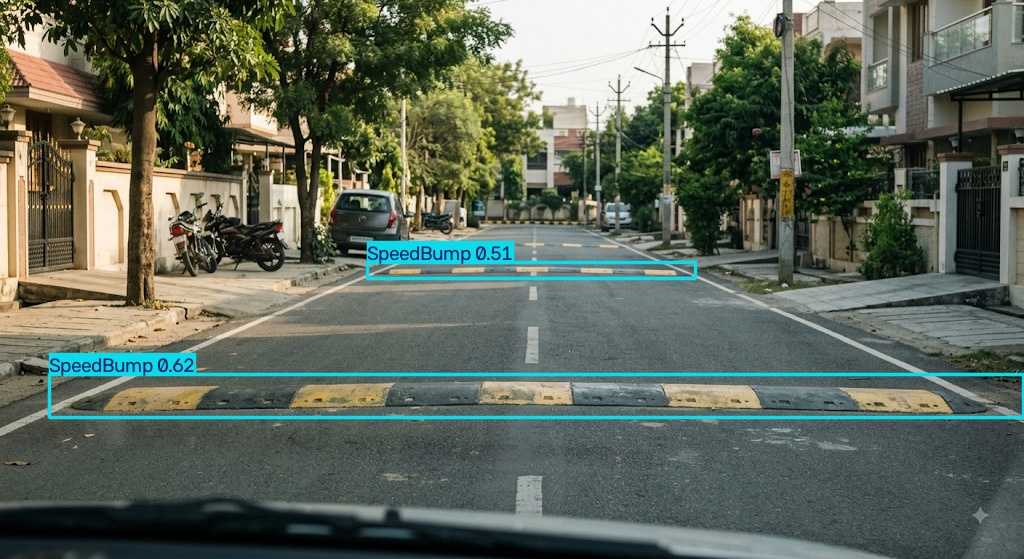

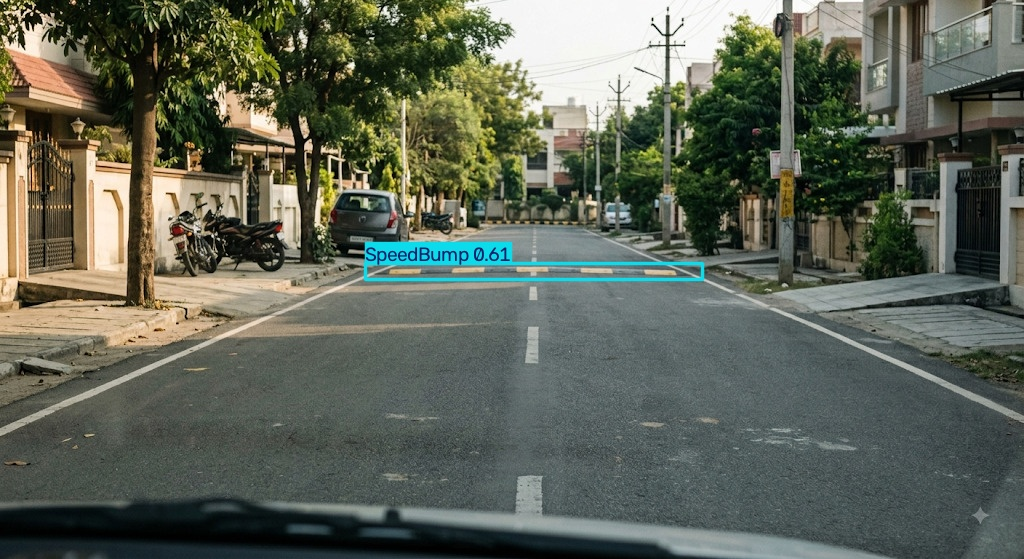

In [3]:
for f in sorted(glob.glob("runs/detect/notebook/*")):
    display(Image(filename=f))